In [302]:
from sklearn.linear_model import LinearRegression
from bokeh.models import HoverTool 
from bokeh.io import export_svg
import numpy as np
import transforms3d as td
import pandas as pd
import bokeh.io
import bokeh.plotting
# Import libraries
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import re
import panel as pn
from bokeh.models import ColumnDataSource
color = bokeh.palettes.d3['Category10'][10]
from bokeh.palettes import Viridis
pn.extension()
import plotly.graph_objects as go
from bokeh.io import export_png
import holoviews as hv
from bokeh.models import CategoricalColorMapper, Legend
from bokeh.layouts import column, row
from bokeh.models import LinearAxis, Range1d
from parse_patient_data import PatientData
import plotly.express as px
import plotly.express as px
bokeh.io.output_notebook()

Loading BokehJS ...

In [449]:
class ParseData(object):
    def __init__(self, df, hand_opens, condition):
        self.df = df
        self.hand_opens = hand_opens
        self.conditions = [condition]#list(self.hand_opens.keys())
        
        self.opens_dfs = self.make_condition_df()
        self.stiffnesses = self.make_condition_df()
        self.intercepts = self.make_condition_df()
        self.fit  = self.make_condition_df()
        self.max_emg = self.make_condition_df()
        self.avg_fit = self.make_condition_df()

        self.splice_condition()
        self.get_stats()
        self.calculate_avg_fit()
        
    def make_condition_df(self):
        return {c: [] for c in self.conditions}
    
    def splice_condition(self):
        '''
        Create the dataframe slice for each condition.
        Also calls the splice_opens and calculate_opens as it iterates over the conditions
        '''
        self.condition_dfs = {}
        for condition in self.conditions:

            # Splice out opens! 
            self.splice_opens(condition)
            # Calculate best fit per hand open
            self.calculate_opens(condition)

            # Concat the hand open dfs to make the condition_df
            condition_df = pd.concat(self.opens_dfs[condition], axis=0)
            condition_df.reset_index(inplace=True)
            condition_df.rename(columns={'level_0' : 'open_index', 'index' : 'full_index'}, inplace=True)
            self.condition_dfs[condition] = condition_df
    
    def splice_opens(self, condition):
        '''
        Create dataframe slices from the manually spliced hand_opens dict
        '''
        for i, j in self.hand_opens[condition]:
            # Get hand opening dataframe slice
            df_slice = self.df.loc[np.r_[i:j]].copy()
            df_slice.reset_index(inplace=True, drop=False)
            self.opens_dfs[condition].append(df_slice)
    
    def calculate_opens(self, condition):
        '''
        Calculate the best fit line for every hand opening.
        '''
        for i, df in enumerate(self.opens_dfs[condition]):
            # Calculate best fit
            df_, m, b = self.calculate_fit(df.copy())
            self.opens_dfs[condition][i] = df_
            
            self.stiffnesses[condition].append(m)
            self.intercepts[condition].append(b)
            self.fit[condition].append((m, b))

            # Get max emg value
            self.max_emg[condition].append(self.get_max_emg(df.copy()))

    def calculate_fit(self, df):
        '''
        Calculate the best fit line for a single hand opening.
        '''
        x_start = df.loc[0,'motor_position']
        y_start = df.loc[0,'futek']

        df['displacement'] = df['motor_position'] - x_start
        df['net_force'] = df['futek'] - y_start

        x_vals = df['displacement'].values.reshape(-1, 1)
        y_vals = df['net_force'].values

        model = LinearRegression()
        model.fit(x_vals, y_vals)
        m = model.coef_[0]
        b = model.intercept_

        return df, m, b

    def get_max_emg(self, df):
        '''
        Calculates the max emg value reached during one hand opening
        '''
        emg_vals = df[['emg%i'%i for i in range(8)]].values
        emg_vals = emg_vals[~np.isnan(emg_vals)]

        return emg_vals.mean()

    def get_stats(self):
        dfs = []

        for c in self.conditions:
            dfs.append(pd.DataFrame(self.stiffnesses[c]).describe().rename(columns = {0 : c}))

        self.stats = pd.concat(dfs, axis = 1)
        
    def calculate_avg_fit(self):
        for c in self.conditions:
            m = np.mean(self.stiffnesses[c])
            b = np.mean(self.intercepts[c])
            self.avg_fit[c] = (m, b)

In [430]:
class PatientData(object):
    def __init__(self, filename):
        self.filename = filename
        
        self.file_to_df()
        
        self.max_emg = self.df[['emg%i'%i for i in range(8)]].values.max()
        
    def file_to_df(self):

        df = pd.read_csv(self.filename, low_memory=False, index_col=0)
        
        # Remove NaN rows from dataframe
        df = df[~df['motor_position'].isnull()]
        df = df[~df['futek'].isnull()]
        df.reset_index(inplace = True, drop = True)

        # Convert motor_position to mm
        df['motor_position'] = df['motor_position'] * 0.007 # encoder to mm
        
        df['time_elapsed'] = df['time_elapsed'] - df.loc[0, 'time_elapsed']
        # define df attribute
        self.df = df

    def plot_futek_time(self):
        hover = HoverTool(tooltips=[("index", "$index"),])
        
        p = bokeh.plotting.figure(
                        width=1200,
                        height=600,
                        x_axis_label="time (s)",
                        y_axis_label="Force (Newtons)",
                        #title = '',
                        #x_range = [-45, 110],
                        y_range = [-1, 15],
                        tools = [hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset']
                    )
        p.extra_y_ranges = {"emg": Range1d(start=0, end=self.max_emg + 50)}
        p.add_layout(LinearAxis(y_range_name="emg", axis_label='Myo EMG Amplitude (a.u.)'), 'right')
        # Keep legend outside of plot
        p.add_layout(Legend(), 'right')

        p.line(x = p3.df['time_elapsed'], y = self.df['futek'], color = color[0], line_width = 5, legend_label = 'force')

        for i in range(8):
            p.line(x = p3.df['time_elapsed'], y = self.df['emg%i'%i], color = color[i], line_alpha = 0.7, legend_label = 'emg', y_range_name='emg')

        p.legend.click_policy='hide'
        
        return p
    
    def plot_futek_displacement(self):
        fig = px.scatter_3d(p3.df, x='motor_position', y='time_elapsed', z='futek', color = 'time_elapsed', width=800, height=800)
        return fig

In [486]:
class PlotData(object):
    def __init__(self, patient):
        self.data = patient
        self.plot_label = {'passive_start': 'Passive 1',
                            'passive_end': 'Passive 2',
                            'active_rorcr': 'Active 1',
                            'active_rorcr1': 'T4',
                            'active_cube': 'Active 2',
                            'mcp_angle': 'MCP Angle (deg)',
                            'pip_angle': 'PIP Angle (deg)',
                            'stiffness': 'Index Finger Stiffness (N/mm)',
                            'mcp_m' : 'MCP Joint Stiffness (Nmm/deg)',
                            'pip_m' : 'PIP Joint Stiffness (Nmm/deg)',
                            'torque_mcp' : 'MCP Joint Torque (Nmm)',
                            'torque_pip' : 'PIP Joint Torque (Nmm)',
                            'displacement': 'Cable Displacement (mm)',
                            'motor_position' : 'Cable Retraction (mm)',
                            'futek': 'Force (N)',
                            'net_force' : 'Net Force (N)',
                            'time_open': 'Time over Experimental Condition (unscaled)',
                            'time_unitless' : 'Time over Experiment',
                            'p1': 'S1',
                            'p13': 'S2',
                            'p3': 'S3',
                            'p3_003' : '003', 
                            'p3_002' : '002', 
                            'p3_001' : '001'}

    def p_format(self, p):
        p.title.text_font_size = '30pt'
        p.title.align = 'center'
        p.legend.label_text_font_size = '25pt'
        p.xaxis.axis_label_text_font_size = '25pt'
        p.yaxis.axis_label_text_font_size = '25pt'
        p.yaxis.major_label_text_font_size = '20pt'
        p.xaxis.major_label_text_font_size = '20pt'
        return p

    def plot_stiffness(self, title = 'Index Finger Stiffness'):

        hover = HoverTool(tooltips=[("index", "$index"),])
        p = bokeh.plotting.figure(
                width=1000,
                height=600,
                x_axis_label= 'Opening Cycle #',
                y_axis_label=self.plot_label['stiffness'],
                title = title,
                tools = [hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset'],
                y_range = [0, 0.87]
            )
        p.add_layout(Legend(), 'right')
        color = bokeh.palettes.d3['Category10'][10]
        n = 0

        for i, condition in enumerate(self.data.conditions):
            p.circle(np.arange(n, len(self.data.stiffnesses[condition])+n), self.data.stiffnesses[condition], legend_label = self.plot_label[condition], color = color[i], alpha = 1, size =12)
            #p.line(np.arange(n, len(self.data.stiffnesses[condition])+n), self.data.stiffnesses[condition], legend_label = condition, color = color[i], alpha = 0.5)
            p.segment(x0=np.arange(n, len(self.data.stiffnesses[condition])+n),x1=np.arange(n, len(self.data.stiffnesses[condition])+n), y0=0, y1 = self.data.stiffnesses[condition], 
                      legend_label = self.plot_label[condition], 
                      color = color[i], 
                      alpha = 0.5, 
                      line_width = 3)
            n += len(self.data.stiffnesses[condition])
        
        p = self.p_format(p)

        return p


    def plot_opens(self, open_set = False, save = False, x_max = 25, y_max = 12, n_start = 0, n_end = 10):
        hover = HoverTool(tooltips=[("index", "$index"),])
        p = bokeh.plotting.figure(
                width=800,
                height=600,
                x_axis_label="Cable Displacement (mm)",
                y_axis_label="Force (N)",
                title = 'Force vs. Displacement',
                x_range = [0, x_max],
                y_range = [0, y_max],
                tools = [hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset']
            )
        color = bokeh.palettes.d3['Category10'][10]
        # Keep legend outside of plot
        p.add_layout(Legend(), 'right')
        
        for i, condition in enumerate(self.data.conditions):
            for df in self.data.opens_dfs[condition][n_start:n_end]:
                p.line(
                    df['displacement'],
                    df['futek'],
                    color=color[i],
                    legend_label=self.plot_label[condition],
                    line_width=3,
                    alpha=0.5
                )
                p.circle(
                    df['displacement'],
                    df['futek'],
                    color=color[i],
                    legend_label=self.plot_label[condition],
                    line_width=5,
                    alpha=0.3
                )
            
                
        #p.vbar(x= np.mean([-45, 110]), top = -45, alpha = 0.07, color = 'grey', width = 45+110)
        #p.vbar(x=np.mean([-45, 0]), top=110, alpha=0.07, color="grey", width=45)
        #p.vbar(x=np.mean([-45, 0]), top=-45, alpha=0.1, color="grey", width=45)
        p.legend.click_policy='hide'
        p = self.p_format(p)

        return p
    
    def plot_fit(self, open_set = False, save = False, x_max = 25, y_max = 12, n_start = 0, n_end = 10):
        hover = HoverTool(tooltips=[("index", "$index"),])
        p = bokeh.plotting.figure(
                width=800,
                height=600,
                x_axis_label="Cable Displacement (mm)",
                y_axis_label="Force (N)",
                title = 'Force vs. Displacement',
                x_range = [0, x_max],
                y_range = [0, y_max],
                tools = [hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset']
            )
        color = bokeh.palettes.d3['Category10'][10]
        # Keep legend outside of plot
        p.add_layout(Legend(), 'right')
        
        for i, condition in enumerate(self.data.conditions):
            for df in self.data.opens_dfs[condition]:
                p.line(
                    df['displacement'],
                    df['futek'],
                    color=color[i],
                    legend_label=self.plot_label[condition],
                    line_width=1.5,
                    alpha=0.3
                )
                p.circle(
                    df['displacement'],
                    df['futek'],
                    color=color[i],
                    legend_label=self.plot_label[condition],
                    size=0,
                    alpha=0.3
                )
            m, b = self.data.avg_fit[condition]
            x = np.arange(0, x_max)
            p.line(
                x,
                m*x + b,
                color=color[i],
                legend_label=self.plot_label[condition],
                line_width=5,
                alpha=1)
            
                
        #p.vbar(x= np.mean([-45, 110]), top = -45, alpha = 0.07, color = 'grey', width = 45+110)
        #p.vbar(x=np.mean([-45, 0]), top=110, alpha=0.07, color="grey", width=45)
        #p.vbar(x=np.mean([-45, 0]), top=-45, alpha=0.1, color="grey", width=45)
        p.legend.click_policy='hide'
        p = self.p_format(p)

        return p

p3 = PlotData(p3_data)

# Load in data file

In [511]:
file = '/Users/kate/Downloads/p3_vibration_data/p3_003.csv'

p3 = PatientData(file)
p3.df

,gt,time_elapsed,current_time,current_task,futek,motor_position,emg0,emg1,emg2,emg3,emg4,emg5,emg6,emg7
0,0,0.000000,20240917142822211,NaN,0.0,0.133,24,22,28,23,27,26,25,27
1,0,0.009995,20240917142822221,NaN,0.0,0.133,21,25,27,28,27,28,27,30
2,0,0.019864,20240917142822231,NaN,0.0,0.133,21,23,25,28,28,28,29,31
3,0,0.029859,20240917142822241,NaN,0.0,0.133,21,23,27,28,28,28,25,28
4,0,0.039837,20240917142822251,NaN,0.0,0.133,21,23,27,28,28,28,25,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5383,0,53.829975,20240917142916041,NaN,0.0,0.133,33,27,28,33,32,41,47,47
5384,0,53.839973,20240917142916051,NaN,0.0,0.133,33,27,28,33,32,41,47,47
5385,0,53.849974,20240917142916061,NaN,0.0,0.133,32,28,30,32,32,42,48,44
5386,0,53.861496,20240917142916073,NaN,0.0,0.133,32,28,30,32,32,42,48,44


# Visualize Force vs. Time

In [514]:
p = p3.plot_futek_time()
bokeh.io.show(p)

# Visualize Force vs. Motor position vs. Time

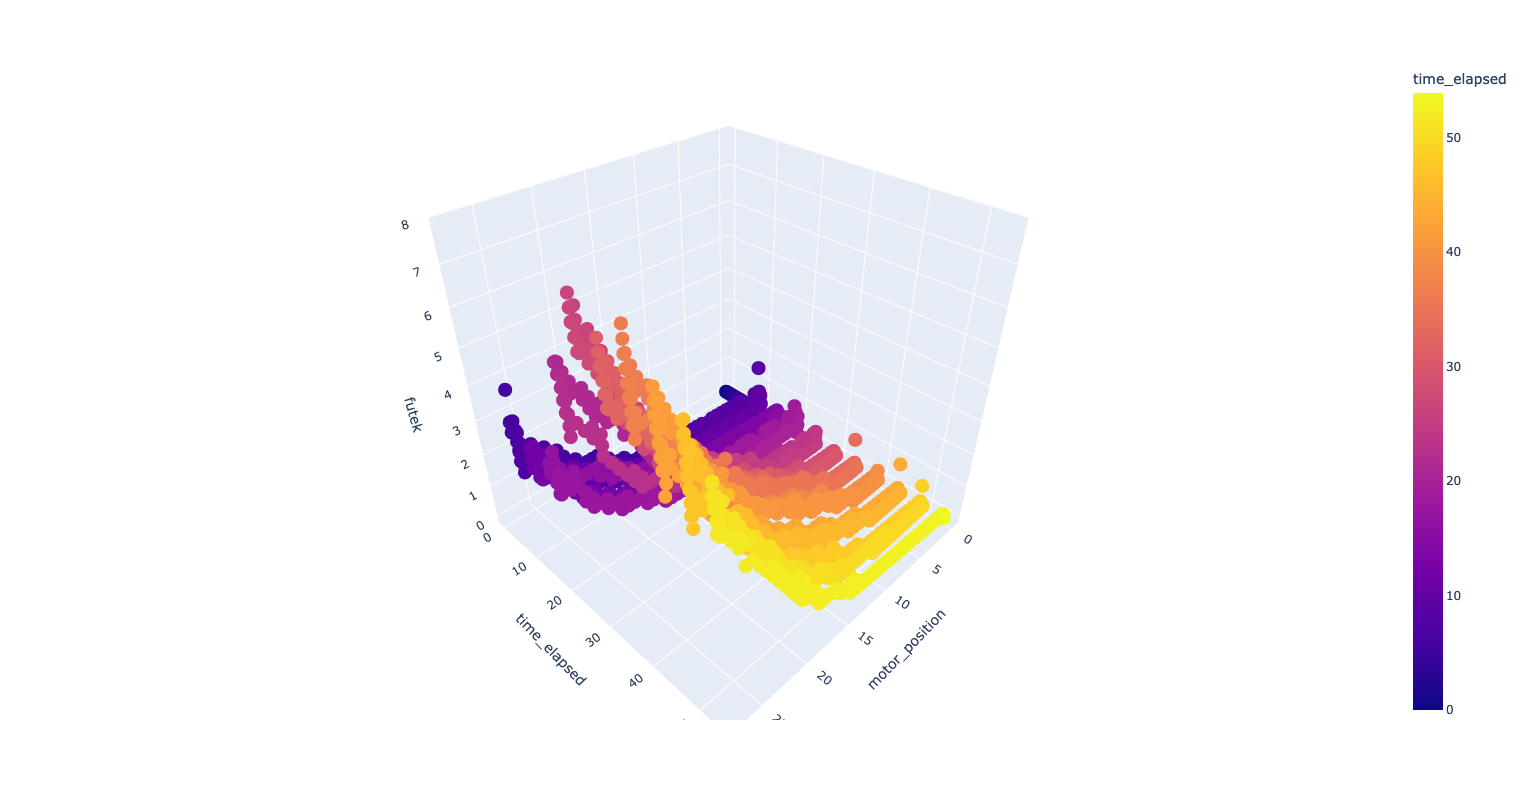

In [517]:
fig = p3.plot_futek_displacement()
fig.show()

In [519]:
p3_data = ParseData(p3.df, p3_opens, 'p3_003')

In [521]:
p3_data.stiffnesses

{'p3_003': [0.2499734862701389,
  0.1990905466049822,
  0.1935995546950728,
  0.33202201746700777,
  0.346348116713809,
  0.2853722767173654,
  0.29730802345405,
  0.2731783725817443,
  0.2808651318340964,
  0.34303819695536786]}

In [525]:
p3_plot = PlotData(p3_data)

In [527]:
bokeh.io.show(p3_plot.plot_fit())

# Let's look at all the data:

In [551]:
# Manually spliced hand opens
p3_opens ={'p3_001' : [[1480, 1623], [2113, 2226], [2637, 2757], [3200, 3332], [3746, 3889], [4253, 4400], [5268, 5393], [5820, 5930]],
           'p3_002' : [[896, 1016], [1392, 1491], [1820, 1917], [2249, 2347], [2695, 2790], [3127, 3224], [3585, 3676], [4052, 4144], [4524, 4618], [5010, 5100]],
           'p3_003' : [[558, 629], [1071, 1145],  [1578, 1671], [2040, 2146], [2519, 2643], [3019, 3147], [3502, 3646], [3998, 4140], [4504, 4634], [5007, 5102]]}
patient_data = {}
patient_plot = {}

In [533]:
for i in range(1, 4):
    file = '/Users/kate/Downloads/p3_vibration_data/p3_00%i.csv'%i
    patient = PatientData(file)
    data = ParseData(patient.df, p3_opens, 'p3_00%i'%i)
    patient_data['p3_00%i'%i] = data
    patient_plot['p3_00%i'%i] = PlotData(data)

In [535]:
patient_data

{'p3_001': <__main__.ParseData at 0x3031545d0>,
 'p3_002': <__main__.ParseData at 0x303086f50>,
 'p3_003': <__main__.ParseData at 0x3035f1950>}

In [549]:

for p in patient_plot.values():
    bokeh.io.show(p.plot_fit())